In [29]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
import seaborn as sn
import tensorflow as tf
from keras.layers import (
    BatchNormalization,
    Conv2D,
    Dense,
    Dropout,
    Flatten,
    GlobalAveragePooling2D,
    Input,
    MaxPooling2D,
    RandomBrightness,
    RandomCrop,
    RandomFlip,
    RandomGrayscale,
    RandomRotation,
    RandomZoom,
)
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2


In [30]:
# Paths
data_path = Path("../data/flowers-102")
image_path = data_path / "jpg"

# Load labels and official splits
labels = sio.loadmat(data_path / "imagelabels.mat")["labels"].flatten()
set_data = sio.loadmat(data_path / "setid.mat")

train_ids = set_data["trnid"].flatten()
test_ids = set_data["tstid"].flatten()

# Image size
IMG_SIZE = (128, 128)

def load_images(image_ids):
    images = []

    for image_id in image_ids:
        file_path = image_path / f"image_{image_id:05d}.jpg"

        image = Image.open(file_path).convert("RGB")
        image = image.resize(IMG_SIZE)

        images.append(np.array(image))

    return np.array(images)

# Load images
X_train = load_images(train_ids)
X_test = load_images(test_ids)

# Get labels
y_train = labels[train_ids - 1] - 1
y_test = labels[test_ids - 1] - 1



In [31]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1020, 128, 128, 3)
y_train: (1020,)
X_test: (6149, 128, 128, 3)
y_test: (6149,)


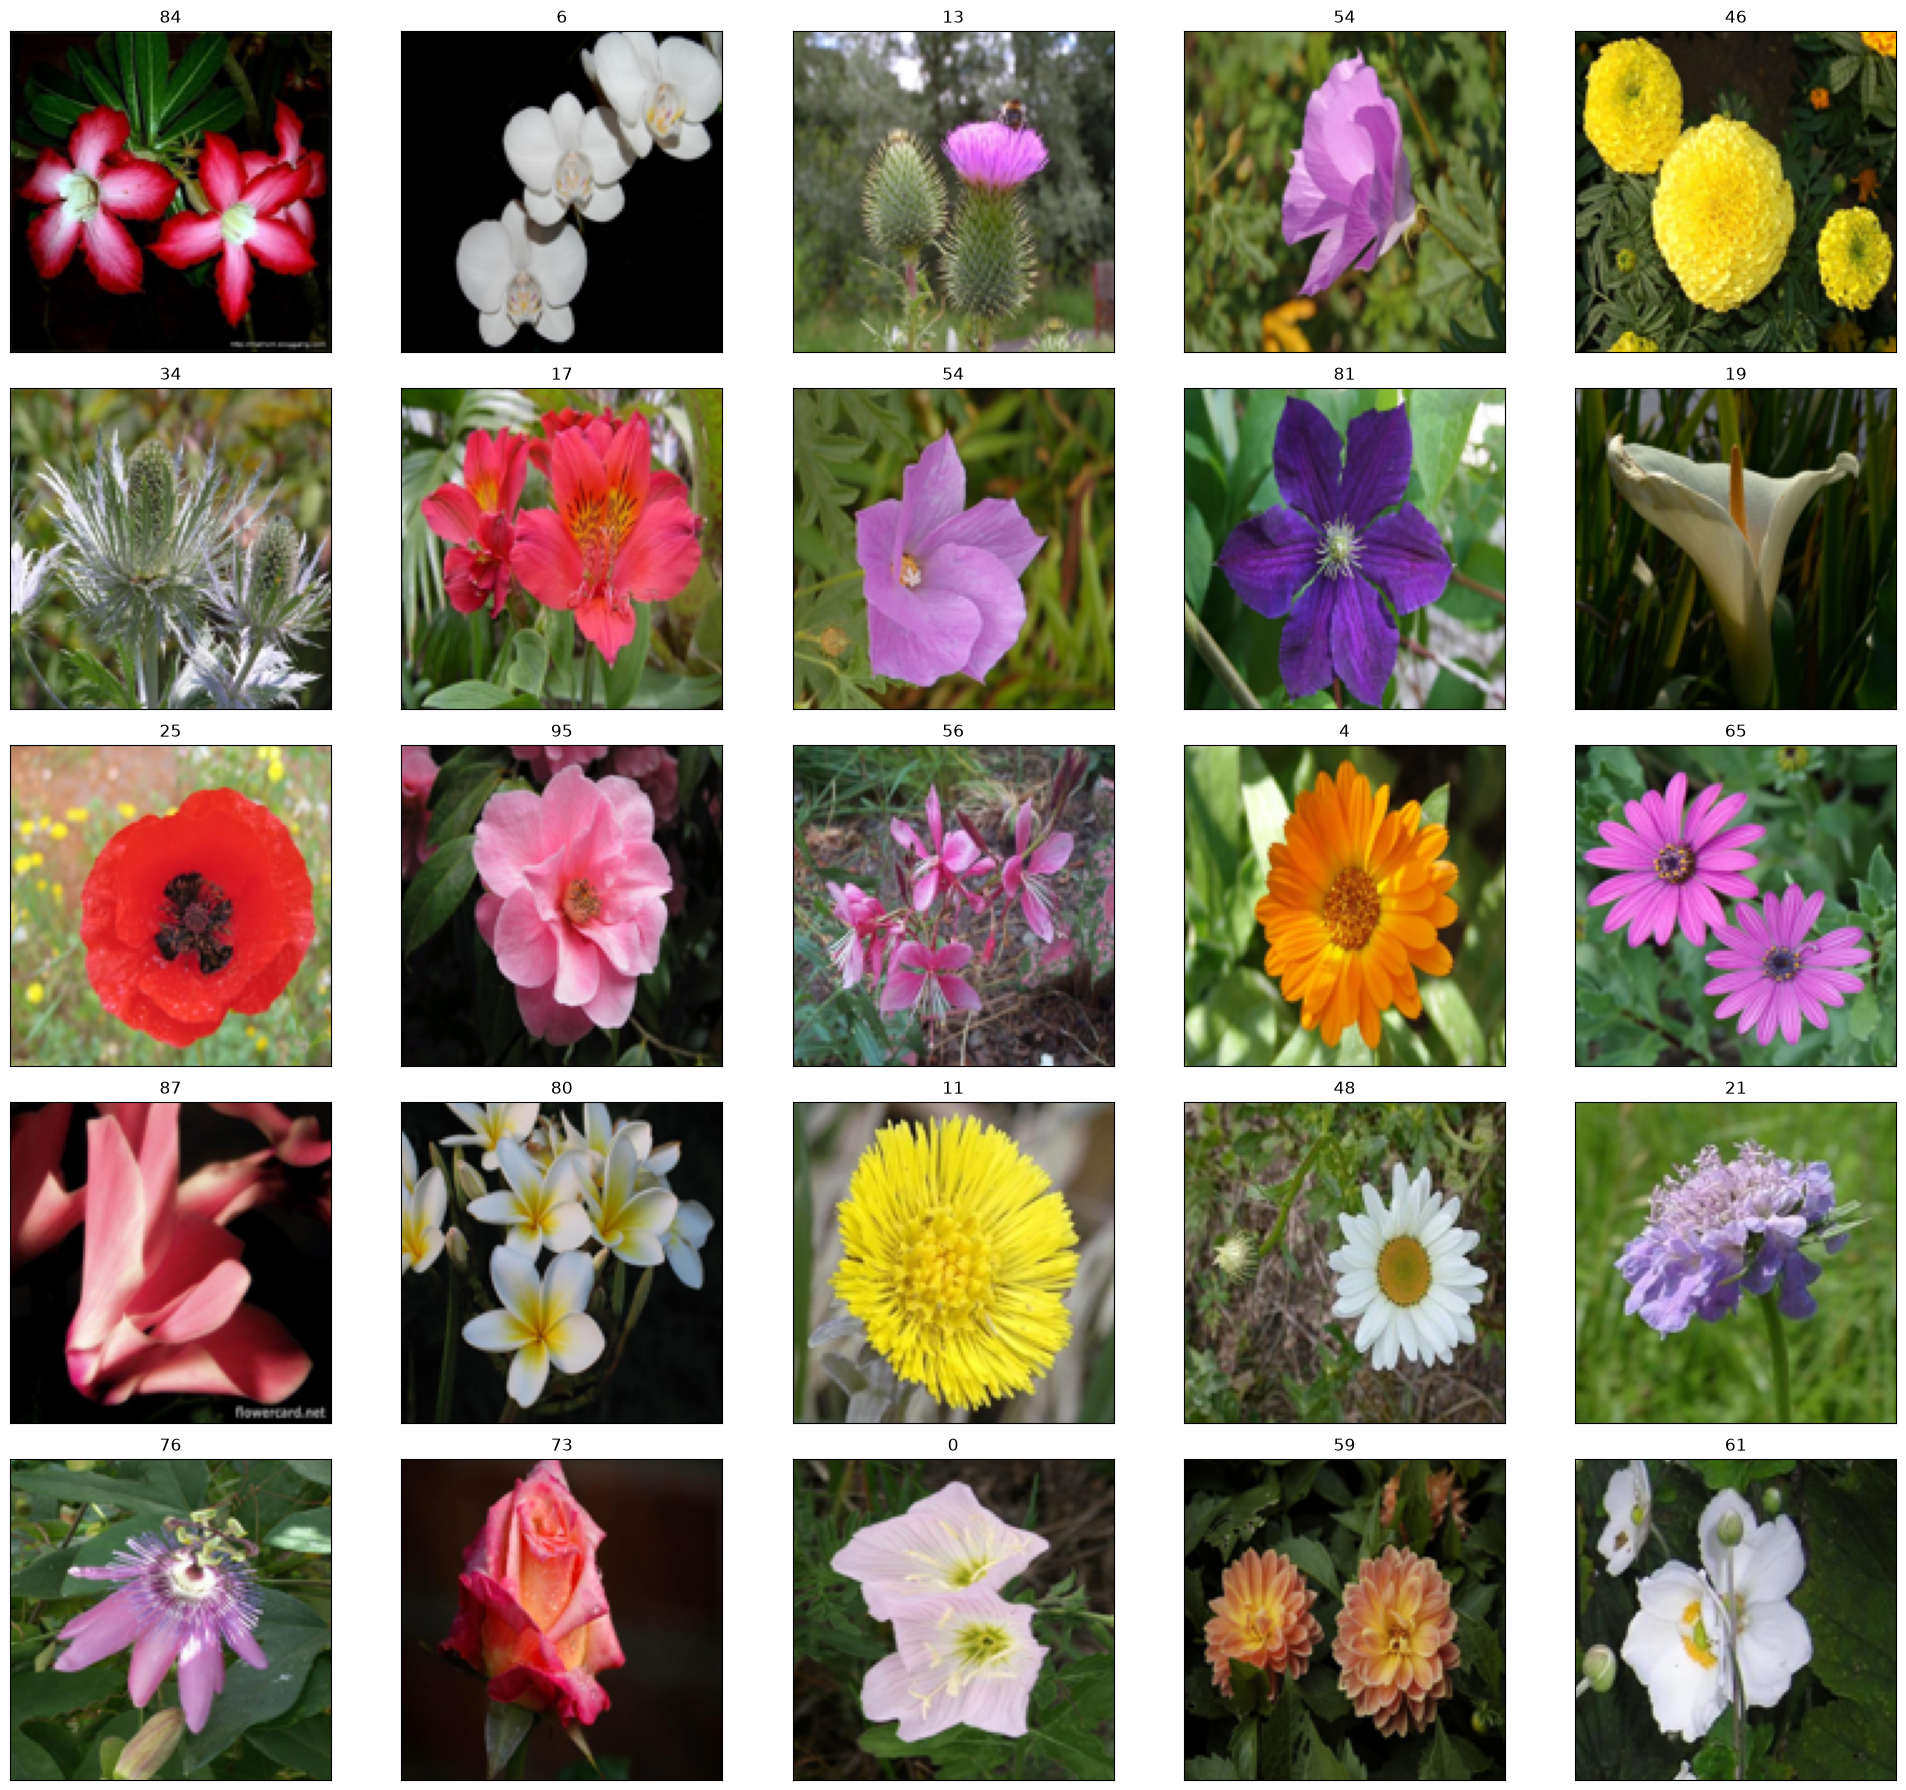

In [32]:
plt.figure(figsize=(20, 18))
indices = np.random.choice(len(X_train), 25, replace=False)
for i, idx in enumerate(indices):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train[idx])
    plt.xticks([])
    plt.yticks([])
    plt.title(
        f"{y_train[idx]}"
    )
plt.tight_layout()
plt.show()

In [33]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [57]:
cnn_baseline = Sequential([
    # Input
    Input(shape = (128, 128, 3)), #0
    
    
    # Data Augmentation
    # RandomRotation(0.2), # 1
    # RandomZoom(0.3), # 2 
    # RandomBrightness(0.3), # 3
    # RandomFlip("horizontal"), # 4
    # RandomGrayscale(0.2), # 5
    
    # Block 1:
    
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        # kernel_regularizer= l2(1e-4),
        padding="same",
        activation="relu"),
    BatchNormalization(),
        
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        # kernel_regularizer= l2(1e-4),
        padding="same",
        activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),
    # Dropout(0.2),
    
    # Block 2:
    Conv2D(
        
        filters = 64,
        kernel_size = (3,3),
        # kernel_regularizer = l2(1e-4),
        activation = "relu",
        padding = "same"
        
    ),
    BatchNormalization(),
      Conv2D(
        
        filters = 64,
        kernel_size = (3,3),
        # kernel_regularizer = l2(1e-4),
        activation = "relu",
        padding = "same"  
    ),
    BatchNormalization(),
    MaxPooling2D(),
    # Dropout(0.4),
    
    
     # Block 3:
    Conv2D(
        
        filters = 128,
        kernel_size = (3,3),
        # kernel_regularizer = l2(1e-4),
        activation = "relu",
        padding = "same"
        
    ),
    BatchNormalization(),
      Conv2D(
        
        filters = 128,
        kernel_size = (3,3),
        # kernel_regularizer = l2(1e-4),
        activation = "relu",
        padding = "same"  
    ),
    BatchNormalization(),
    MaxPooling2D(),
    # Dropout(0.4),
    
    
    GlobalAveragePooling2D(),
    
    # classifier
    
    Dense(128, activation= "relu"),
    # Dropout(0.5),
    Dense(64, activation = "relu"),
    # Dropout(0.3),
    Dense(102, activation="softmax")
    
    
])

In [58]:
cnn_baseline.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 102)            │         6,630 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,198 (1.22 MB)

 Trainable params: 319,302 (1.22 MB)

 Non-trainable params: 896 (3.50 KB)

In [59]:
cnn_baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

In [60]:
callbacks = [
    EarlyStopping(
        monitor = "val_loss",
        mode="min",
        patience=5,
        min_delta = 1e-5,
        restore_best_weights = True,
        verbose=1,
        start_from_epoch = 5
        
    ),
    ReduceLROnPlateau(
        monitor="val_accuracy",
        mode="max",
        patience = 5,
        min_delta = 1e-5,
        min_lr = 1e-6,
        factor = 0.5,
        
    )
]

In [61]:
X_train, X_val, y_train ,y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=42, stratify=y_train)
X_val = X_val.astype("float32") / 255.0

In [62]:
predictions = cnn_baseline(X_train[:16], training=False)
print(type(predictions))
print("Shape:", predictions.shape)
print("NaN:", np.isnan(predictions.numpy()).any())
print("Inf:", np.isinf(predictions.numpy()).any())
print("Min:", predictions.numpy().min())
print("Max:", predictions.numpy().max())
print("Sum:", predictions[0].numpy().sum())

<class 'tensorflow.python.framework.ops.EagerTensor'>
Shape: (16, 102)
NaN: False
Inf: False
Min: 0.009423933
Max: 0.010113658
Sum: 1.0


In [63]:
history = cnn_baseline.fit(
    X_train,
    y_train,
    validation_data = (X_val, y_val),
    epochs = 200,
    verbose=1,
    batch_size = 16,
    callbacks= callbacks
)

Epoch 1/200


I0000 00:00:1786885032.257234   15331 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_73921__.79


21/22 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0149 - loss: 4.6585

I0000 00:00:1786885036.340421   15338 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_73921__.79


22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 732ms/step - accuracy: 0.0143 - loss: 4.6665 - val_accuracy: 0.0133 - val_loss: 4.6270 - learning_rate: 1.0000e-04
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.0115 - loss: 4.5255 - val_accuracy: 0.0067 - val_loss: 4.6307 - learning_rate: 1.0000e-04
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.0229 - loss: 4.4654 - val_accuracy: 0.0067 - val_loss: 4.6401 - learning_rate: 1.0000e-04
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.0458 - loss: 4.4031 - val_accuracy: 0.0133 - val_loss: 4.6563 - learning_rate: 1.0000e-04
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.0573 - loss: 4.3540 - val_accuracy: 0.0067 - val_loss: 4.6686 - learning_rate: 1.0000e-04
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.0688 - loss: 4.2850 - val_accuracy: 0.0133 - val_loss: 4.6971 - learning_rate: 1.0000e-04
Epoch 7/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.0860 - l

In [41]:
print(X_train.dtype)
print(X_train.min(), X_train.max())
print(np.isnan(X_train).any())
print(np.isinf(X_train).any())

float32
0.0 1.0
False
False


In [42]:
x_batch = X_train[:16]
y_batch = y_train[:16]

with tf.GradientTape() as tape:
    predictions = cnn_baseline(x_batch, training=True)
    loss = cnn_baseline.compiled_loss(
        y_batch,
        predictions,
        regularization_losses=cnn_baseline.losses,
    )

gradients = tape.gradient(loss, cnn_baseline.trainable_variables)

print("Loss:", loss.numpy())
print("Loss NaN:", np.isnan(loss.numpy()))

print(
    "Gradient NaN:",
    any(
        g is not None and np.isnan(g.numpy()).any()
        for g in gradients
    )
)

print(
    "Gradient Inf:",
    any(
        g is not None and np.isinf(g.numpy()).any()
        for g in gradients
    )
)

Loss: 4.6972265
Loss NaN: False
Gradient NaN: False
Gradient Inf: False


/home/lenovo/Projects/Deep-Learning-Lab/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/trainer.py:696: UserWarning: `model.compiled_loss()` is deprecated. Instead, use `model.compute_loss(x, y, y_pred, sample_weight, training)`.
  warnings.warn(


In [43]:
predictions_train = cnn_baseline(
    X_train[:16],
    training=True
)

print("NaN:", np.isnan(predictions_train.numpy()).any())
print("Inf:", np.isinf(predictions_train.numpy()).any())

NaN: False
Inf: False


In [44]:
x  =X_train[:20]
for layer in cnn_baseline.layers[0:20]:
    x = layer(x, training=True)
    
    print(layer.name,"\n",
          "NaN", np.isnan(x.numpy()).any(),
          "Inf", np.isinf(x.numpy()).any())

random_rotation_1 
 NaN False Inf False
random_zoom_1 
 NaN False Inf False
random_brightness_1 
 NaN False Inf False
random_flip_1 
 NaN False Inf False
random_grayscale_1 
 NaN False Inf False
conv2d_6 
 NaN False Inf False
batch_normalization_6 
 NaN False Inf False
conv2d_7 
 NaN False Inf False
batch_normalization_7 
 NaN False Inf False
max_pooling2d_3 
 NaN False Inf False
dropout_5 
 NaN False Inf False
conv2d_8 
 NaN False Inf False
batch_normalization_8 
 NaN False Inf False
conv2d_9 
 NaN False Inf False
batch_normalization_9 
 NaN False Inf False
max_pooling2d_4 
 NaN False Inf False
dropout_6 
 NaN False Inf False
conv2d_10 
 NaN False Inf False
batch_normalization_10 
 NaN False Inf False
conv2d_11 
 NaN False Inf False


In [45]:
conv2d  = cnn_baseline.get_layer("conv2d")
weights = conv2d.get_weights()

for i, w in enumerate(weights):
    print(
        i,
        "shape:", w.shape,
        "NaN:", np.isnan(w).any(),
        "Inf:", np.isinf(w).any(),
        "min:", w.min(),
        "max:", w.max(),
    )

ValueError: No such layer: conv2d. Existing layers are: ['random_rotation_1', 'random_zoom_1', 'random_brightness_1', 'random_flip_1', 'random_grayscale_1', 'conv2d_6', 'batch_normalization_6', 'conv2d_7', 'batch_normalization_7', 'max_pooling2d_3', 'dropout_5', 'conv2d_8', 'batch_normalization_8', 'conv2d_9', 'batch_normalization_9', 'max_pooling2d_4', 'dropout_6', 'conv2d_10', 'batch_normalization_10', 'conv2d_11', 'batch_normalization_11', 'max_pooling2d_5', 'global_average_pooling2d_1', 'dense_3', 'dropout_7', 'dense_4', 'dropout_8', 'dense_5'].

In [ ]:
for i, w in enumerate(weights):
    print(i, w.shape)

0 (3, 3, 3, 32)
1 (32,)


In [ ]:
conv = cnn_baseline.get_layer("conv2d")

weights = conv.get_weights()

for i, w in enumerate(weights):
    print(
        i,
        "shape:", w.shape,
        "NaN:", np.isnan(w).any(),
        "Inf:", np.isinf(w).any(),
        "min:", w.min(),
        "max:", w.max(),
    )

0 shape: (3, 3, 3, 32) NaN: False Inf: False min: -0.13847557 max: 0.13908184
1 shape: (32,) NaN: False Inf: False min: -0.0056313477 max: 0.0046768826


In [ ]:
fresh_model = keras.models.clone_model(cnn_baseline)

conv = fresh_model.get_layer("conv2d")

for i, w in enumerate(conv.get_weights()):
    print(
        i,
        "NaN:", np.isnan(w).any(),
        "Inf:", np.isinf(w).any(),
        "min:", w.min(),
        "max:", w.max(),
    )

0 NaN: False Inf: False min: -0.13796513 max: 0.13800634
1 NaN: False Inf: False min: 0.0 max: 0.0


In [ ]:
fresh_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

fresh_model.train_on_batch(
    X_train[:16],
    y_train[:16],
)

conv = fresh_model.get_layer("conv2d")

for i, w in enumerate(conv.get_weights()):
    print(
        i,
        "NaN:", np.isnan(w).any(),
        "Inf:", np.isinf(w).any(),
        "min:", np.nanmin(w),
        "max:", np.nanmax(w),
    )

E0000 00:00:1786883934.403871   15081 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


0 NaN: False Inf: False min: -0.13806504 max: 0.13791662
1 NaN: False Inf: False min: -9.997298e-05 max: 9.9991485e-05


In [ ]:
fresh_model.train_on_batch(
    X_train[16:32],
    y_train[16:32],
)

conv = fresh_model.get_layer("conv2d")

for i, w in enumerate(conv.get_weights()):
    print(
        i,
        "NaN:", np.isnan(w).any(),
        "Inf:", np.isinf(w).any(),
        "min:", np.nanmin(w),
        "max:", np.nanmax(w),
    )

0 NaN: False Inf: False min: -0.13813594 max: 0.13782412
1 NaN: False Inf: False min: -0.00019962514 max: 0.00018304588


In [ ]:
loss_1 = fresh_model.evaluate(
    X_train[:16],
    y_train[:16],
    verbose=0,
)

loss_2 = fresh_model.evaluate(
    X_train[16:32],
    y_train[16:32],
    verbose=0,
)

print("Batch 1:", loss_1)
print("Batch 2:", loss_2)

Batch 1: [4.661312580108643, 0.0]
Batch 2: [4.660066604614258, 0.0]


In [ ]:
for i in range(100):
    start = i * 16
    end = start + 16

    loss, accuracy = fresh_model.train_on_batch(
        X_train[start:end],
        y_train[start:end],
    )

    print(
        f"Batch {i + 1}: "
        f"loss={loss:.4f}, "
        f"accuracy={accuracy:.4f}"
    )

Batch 1: loss=5.3906, accuracy=0.0000
Batch 2: loss=5.0347, accuracy=0.0000
Batch 3: loss=4.9465, accuracy=0.0625
Batch 4: loss=5.1322, accuracy=0.0625
Batch 5: loss=5.0538, accuracy=0.0000
Batch 6: loss=5.2502, accuracy=0.0000
Batch 7: loss=5.1505, accuracy=0.0625
Batch 8: loss=5.2940, accuracy=0.0000
Batch 9: loss=4.8915, accuracy=0.0000
Batch 10: loss=5.0470, accuracy=0.0000
Batch 11: loss=5.2298, accuracy=0.0000
Batch 12: loss=4.4257, accuracy=0.0000
Batch 13: loss=5.2417, accuracy=0.0000
Batch 14: loss=4.7284, accuracy=0.0000
Batch 15: loss=4.8696, accuracy=0.0000
Batch 16: loss=4.7278, accuracy=0.0000
Batch 17: loss=4.9832, accuracy=0.0000
Batch 18: loss=5.0579, accuracy=0.0000
Batch 19: loss=5.1397, accuracy=0.0000
Batch 20: loss=5.0583, accuracy=0.0000
Batch 21: loss=5.2364, accuracy=0.0625
Batch 22: loss=5.0310, accuracy=0.0000
Batch 23: loss=4.8258, accuracy=0.0000
Batch 24: loss=5.1512, accuracy=0.0000
Batch 25: loss=4.8586, accuracy=0.0000
Batch 26: loss=5.1808, accuracy=0.

In [ ]:
start = 17 * 16
end = start + 16

print("Batch 18 labels:")
print(y_train[start:end])

print("Minimum:", y_train[start:end].min())
print("Maximum:", y_train[start:end].max())

Batch 18 labels:
[101  64  56  86  33  35  28  33  90   1   1  85  71  29  54  58]
Minimum: 1
Maximum: 101


In [55]:
cnn_baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [56]:
history_debug =cnn_baseline.fit(
    X_train[:16],
    y_train[:16],
    epochs=100,
    batch_size=16,
    verbose=1,
)

Epoch 1/100


I0000 00:00:1786884956.828073   15329 service.cc:153] XLA service 0x7d39e806ccd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786884956.828109   15329 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1786884956.924390   15329 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786884957.516158   15329 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_66144__.68
I0000 00:00:1786884966.563789   15329 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.0000e+00 - loss: 4.6157
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.0000e+00 - loss: 4.4692
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.0000e+00 - loss: 4.3389
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.0625 - loss: 4.2260
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.1875 - loss: 4.1255
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3125 - loss: 4.0305
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.3750 - loss: 3.9434
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4375 - loss: 3.8595
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5000 - loss: 3.7787
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5000 - loss: 3.7014
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5625 - loss: 3.6255
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5625 - lo